In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import sys
import pickle
import os

# sys.path.append('/Users/nmehlman/Library/Mobile Documents/com~apple~CloudDocs/Desktop/CSCI 699/Project/poison-perf')
cwd = os.getcwd()
root = os.path.dirname(cwd)
sys.path.append(root)

from utils.algorithms import RGD, PerfGD
from utils.experiment_setup import setup_1d_non_linear_experiment, setup_binary_classification, setup_non_convex_nd
from poisoning.oracle import oracle_poison_function, RGD_update_estimator, PerfGD_update_estimator, classification_sampling_estimator, gaussian_sampling_estimator
from poisoning.white_box import white_box_poison_function
from poisoning.black_box import black_box_poison_naive, black_box_poison_cluster, black_box_poison_orthogonal
from utils.plotting import plot_results_1d, plot_results_2d

# Non-linear Means

In [ ]:
# Experiment setup
a0 = 1.0
a1 = 1.0

proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)
mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat, info = setup_1d_non_linear_experiment(a0=a0, a1=a1, perfGD=True)

# Hyperparameters
n = 500
eta = 0.05
max_iter = 30
normalize_grad = True
delta_vals = np.linspace(0.0, 2, 49)
epsilon = 0.5
poison_step_size = 0.1
norm = 'linf'
n_trials_per_delta = 10

## RGD

In [ ]:
# Clean training
theta_clean_avg = []
loss_clean_avg = []
for trial in range(n_trials_per_delta):
    theta_clean, _, all_losses_clean = RGD(
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    proj_theta=proj_theta,
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    return_losses=True,
                    normalize_grad=normalize_grad
        )

    theta_clean_avg.append(theta_clean.item())
    loss_clean_avg.append(all_losses_clean[-1])
    
theta_clean = np.mean(theta_clean_avg)
loss_clean = np.mean(loss_clean_avg)

### Black Box Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=black_box_poison_naive,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad,
                return_losses=True,
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned.item())
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-linear-means/RGD/non-linear-means_RGD_black_box.pkl', 'wb'))

### White Box Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=white_box_poison_function,
                theta_update_estimator=RGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad,
                return_losses=True,
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned.item())
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-linear-means/RGD/non-linear-means_RGD_white_box.pkl', 'wb'))

### Oracle Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    proj_theta=proj_theta,
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    poison_function=oracle_poison_function,
                    theta_update_estimator=RGD_update_estimator,
                    sampling_estimator=gaussian_sampling_estimator,
                    sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
                    poison_steps=int(float(delta)//poison_step_size) + 1,
                    poison_step_size=poison_step_size,
                    epsilon=epsilon,
                    delta=delta,
                    return_losses=True,
                    norm=norm,
                    normalize_grad=normalize_grad
        )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned.item())
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-linear-means/RGD/non-linear-means_RGD_oracle.pkl', 'wb'))

### Plots

In [ ]:
white_box_data = pickle.load(open('../exports/non-linear-means/RGD/non-linear-means_RGD_white_box.pkl', 'rb'))
oracle_data = pickle.load(open('../exports/non-linear-means/RGD/non-linear-means_RGD_oracle.pkl', 'rb'))
black_box_data = pickle.load(open('../exports/non-linear-means/RGD/non-linear-means_RGD_black_box.pkl', 'rb'))

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Top: loss difference
axes[0].plot(white_box_data["delta_vals"], white_box_data["loss_diff"], label="White-Box", color="blue")
axes[0].plot(oracle_data["delta_vals"], oracle_data["loss_diff"], label="Oracle", color="red")
axes[0].plot(black_box_data["delta_vals"], black_box_data["loss_diff"], label="Black-Box", color="black")
axes[0].set_ylabel("Loss Diff. (Poisoned - Clean)")
axes[0].set_title("Non-Linear Means / RGD")
axes[0].legend()
axes[0].grid(True)

# Bottom: theta difference
axes[1].plot(white_box_data["delta_vals"], np.abs(white_box_data["theta_diff"]), label="White-Box", color="blue")
axes[1].plot(oracle_data["delta_vals"], np.abs(oracle_data["theta_diff"]), label="Oracle", color="red")
axes[1].plot(black_box_data["delta_vals"], np.abs(black_box_data["theta_diff"]), label="Black-Box", color="black")
axes[1].set_ylabel("Abs. Theta Diff.")
axes[1].set_xlabel(r"$\delta$ Value ($\epsilon=0.5$)")

axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
white_box_data['loss_diff'][white_box_data["delta_vals"]==1.0]

## PerfGD

In [ ]:
# Clean training
theta_clean_avg = []
loss_clean_avg = []
for trial in range(n_trials_per_delta):
    theta_clean, _, all_losses_clean = PerfGD(
                    f_hat=f_hat,
                    grad2_est=grad2_est,
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    proj_theta=proj_theta,
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    return_losses=True,
                    normalize_grad=normalize_grad,
        )

    theta_clean_avg.append(theta_clean.item())
    loss_clean_avg.append(all_losses_clean[-1])
    
theta_clean = np.mean(theta_clean_avg)
loss_clean = np.mean(loss_clean_avg)

### Black Box Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=black_box_poison_naive,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad
        )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned.item())
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-linear-means/PerfGD/non-linear-means_PerfGD_black_box.pkl', 'wb'))

### White Box Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=white_box_poison_function,
                theta_update_estimator=PerfGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size, 
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad
        )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned.item())
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-linear-means/PerfGD/non-linear-means_PerfGD_white_box.pkl', 'wb'))

### Oracle Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=oracle_poison_function,
                theta_update_estimator=PerfGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size, 
                sampling_estimator=gaussian_sampling_estimator,
                sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
                epsilon=epsilon,
                delta=delta,
        )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned.item())
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-linear-means/PerfGD/non-linear-means_PerfGD_oracle.pkl', 'wb'))

### Plots

In [ ]:
white_box_data = pickle.load(open('../exports/non-linear-means/PerfGD/non-linear-means_PerfGD_white_box.pkl', 'rb'))
oracle_data = pickle.load(open('../exports/non-linear-means/PerfGD/non-linear-means_PerfGD_oracle.pkl', 'rb'))
black_box_data = pickle.load(open('../exports/non-linear-means/PerfGD/non-linear-means_PerfGD_black_box.pkl', 'rb'))

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Top: loss difference
axes[0].plot(white_box_data["delta_vals"], white_box_data["loss_diff"], label="White-Box", color="blue")
axes[0].plot(oracle_data["delta_vals"], oracle_data["loss_diff"], label="Oracle", color="red")
axes[0].plot(black_box_data["delta_vals"], black_box_data["loss_diff"], label="Black-Box", color="black")
axes[0].set_ylabel("Loss Diff. (Poisoned - Clean)")
axes[0].set_title("Non-Linear Means / PerfGD")
axes[0].legend()
axes[0].grid(True)

# Bottom: theta difference
axes[1].plot(white_box_data["delta_vals"], np.abs(white_box_data["theta_diff"]), label="White-Box", color="blue")
axes[1].plot(oracle_data["delta_vals"], np.abs(oracle_data["theta_diff"]), label="Oracle", color="red")
axes[1].plot(black_box_data["delta_vals"], np.abs(black_box_data["theta_diff"]), label="Black-Box", color="black")
axes[1].set_ylabel("Abs. Theta Diff.")
axes[1].set_xlabel(r"$\delta$ Value ($\epsilon=0.5$)")

axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Classification

In [ ]:
mu_f, mu_0, sigma_0, sigma_1, D_theta, loss, theta_0, grad2_est, f_hat = setup_binary_classification(perfGD=True)

# Hyperparameters
n = 500
eta = 0.05
max_iter = 30
normalize_grad = True
delta_vals = np.linspace(0.0, 2, 49)
epsilon = 0.5
poison_step_size = 0.1
norm = 'linf'
n_trials_per_delta = 10

## RGD

In [ ]:
# Clean training
theta_clean_avg = []
loss_clean_avg = []
for trial in range(n_trials_per_delta):
    theta_clean, _, all_losses_clean = RGD(
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    return_losses=True,
                    normalize_grad=normalize_grad
        )

    theta_clean_avg.append(theta_clean)
    loss_clean_avg.append(all_losses_clean[-1])
    
theta_clean = np.mean(theta_clean_avg, 0)
loss_clean = np.mean(loss_clean_avg)

### Black Box Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=black_box_poison_cluster,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad,
                return_losses=True,
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/classification/RGD/classification_RGD_black_box.pkl', 'wb'))

### White Box Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=white_box_poison_function,
                theta_update_estimator=RGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad,
                return_losses=True,
                attack_x_only=True
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/classification/RGD/classification_RGD_white_box.pkl', 'wb'))

### Oracle Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    poison_function=oracle_poison_function,
                    theta_update_estimator=RGD_update_estimator,
                    sampling_estimator=classification_sampling_estimator,
                    sampling_estimator_kwargs={'mu_0': mu_0, 'mu_f': mu_f, 'sigma_0': sigma_0, 'sigma_1': sigma_1},
                    poison_steps=int(float(delta)//poison_step_size) + 1,
                    poison_step_size=poison_step_size,
                    epsilon=epsilon,
                    delta=delta,
                    return_losses=True,
                    norm=norm,
                    normalize_grad=normalize_grad,
                    attack_x_only=True
        )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/classification/RGD/classification_RGD_oracle.pkl', 'wb'))

### Plots

In [ ]:
white_box_data = pickle.load(open('../exports/classification/RGD/classification_RGD_white_box.pkl', 'rb'))
oracle_data = pickle.load(open('../exports/classification/RGD/classification_RGD_oracle.pkl', 'rb'))
black_box_data = pickle.load(open('../exports/classification/RGD/classification_RGD_black_box.pkl', 'rb'))

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Top: loss difference
axes[0].plot(white_box_data["delta_vals"], white_box_data["loss_diff"], label="White-Box", color="blue")
axes[0].plot(oracle_data["delta_vals"], oracle_data["loss_diff"], label="Oracle", color="red")
axes[0].plot(black_box_data["delta_vals"], black_box_data["loss_diff"], label="Black-Box", color="black")
axes[0].set_ylabel("Loss Diff. (Poisoned - Clean)")
axes[0].set_title("Classification / RGD")
axes[0].legend()
axes[0].grid(True)

# Bottom: theta difference
axes[1].plot(white_box_data["delta_vals"], np.linalg.norm(white_box_data["theta_diff"], axis=1), label="White-Box", color="blue")
axes[1].plot(oracle_data["delta_vals"], np.linalg.norm(oracle_data["theta_diff"], axis=1), label="Oracle", color="red")
axes[1].plot(black_box_data["delta_vals"], np.linalg.norm(black_box_data["theta_diff"], axis=1), label="Black-Box", color="black")
axes[1].set_ylabel("Theta Diff. Norm")
axes[1].set_xlabel(r"$\delta$ Value ($\epsilon=0.5$)")

axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## PerfGD

In [ ]:
# Clean training
theta_clean_avg = []
loss_clean_avg = []
for trial in range(n_trials_per_delta):
    theta_clean, all_theta_clean, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                normalize_grad=normalize_grad
    )

    theta_clean_avg.append(theta_clean)
    loss_clean_avg.append(all_losses_clean[-1])
    
theta_clean = np.mean(theta_clean_avg, 0)
loss_clean = np.mean(loss_clean_avg)

### Black Box Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=black_box_poison_cluster,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/classification/PerfGD/classification_PerfGD_black_box.pkl', 'wb'))

### White Box Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
        
        try:
            _theta_poisoned, _, all_losses_poisoned = PerfGD(
                    f_hat=f_hat,
                    grad2_est=grad2_est,
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    return_losses=True,
                    poison_function=white_box_poison_function,
                    theta_update_estimator=PerfGD_update_estimator,
                    poison_steps=int(float(delta)//poison_step_size) + 1,
                    poison_step_size=poison_step_size,
                    epsilon=epsilon,
                    delta=delta,
                    normalize_grad=normalize_grad,
                    attack_x_only=True
        )

            losses_poisoned_trial.append(all_losses_poisoned[-1])
            theta_poisoned_trial.append(_theta_poisoned)
        
        except Exception as e:
            print(f"Error encountered at delta={delta}, trial={trial}: {e}")
            continue
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/classification/PerfGD/classification_PerfGD_white_box.pkl', 'wb'))

### Oracle Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

torch.random.manual_seed(123)

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
        try:
            _theta_poisoned, _, all_losses_poisoned = PerfGD(
                    f_hat=f_hat,
                    grad2_est=grad2_est,
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    return_losses=True,
                    poison_function=oracle_poison_function,
                    theta_update_estimator=PerfGD_update_estimator,
                    poison_steps=int(float(delta)//poison_step_size) + 1,
                    poison_step_size=poison_step_size,
                    epsilon=epsilon,
                    delta=delta,
                    sampling_estimator=classification_sampling_estimator,
                    sampling_estimator_kwargs={'mu_0': mu_0, 'mu_f': mu_f, 'sigma_0': sigma_0, 'sigma_1': sigma_1},
                    normalize_grad=normalize_grad,
                    attack_x_only=True
        )
            
        except Exception as e:
            print(f"Error encountered at delta={delta}, trial={trial}: {e}")
            continue

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/classification/PerfGD/classification_PerfGD_oracle.pkl', 'wb'))

### Plots

In [ ]:
white_box_data = pickle.load(open('../exports/classification/PerfGD/classification_PerfGD_white_box.pkl', 'rb'))
oracle_data = pickle.load(open('../exports/classification/PerfGD/classification_PerfGD_oracle.pkl', 'rb'))
black_box_data = pickle.load(open('../exports/classification/PerfGD/classification_PerfGD_black_box.pkl', 'rb'))

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Top: loss difference
axes[0].plot(white_box_data["delta_vals"], white_box_data["loss_diff"], label="White-Box", color="blue")
axes[0].plot(oracle_data["delta_vals"], oracle_data["loss_diff"], label="Oracle", color="red")
axes[0].plot(black_box_data["delta_vals"], black_box_data["loss_diff"], label="Black-Box", color="black")
axes[0].set_ylabel("Loss Diff. (Poisoned - Clean)")
axes[0].set_title("Classification / PerfGD")
axes[0].legend()
axes[0].grid(True)

# Bottom: theta difference
axes[1].plot(white_box_data["delta_vals"], np.linalg.norm(white_box_data["theta_diff"], axis=1), label="White-Box", color="blue")
axes[1].plot(oracle_data["delta_vals"], np.linalg.norm(oracle_data["theta_diff"], axis=1), label="Oracle", color="red")
axes[1].plot(black_box_data["delta_vals"], np.linalg.norm(black_box_data["theta_diff"], axis=1), label="Black-Box", color="black")
axes[1].set_ylabel("Abs. Theta Diff.")
axes[1].set_xlabel(r"$\delta$ Value ($\epsilon=0.5$)")

axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 10-Dimensional Non-Convex

In [2]:
mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat = setup_non_convex_nd(perfGD=True)

# Hyperparameters
n = 500
eta = 0.02
max_iter = 200
normalize_grad = True
delta_vals = np.linspace(0.0, 2, 49)
epsilon = 0.5
poison_step_size = 0.1
norm = 'linf'
n_trials_per_delta = 10

## RGD

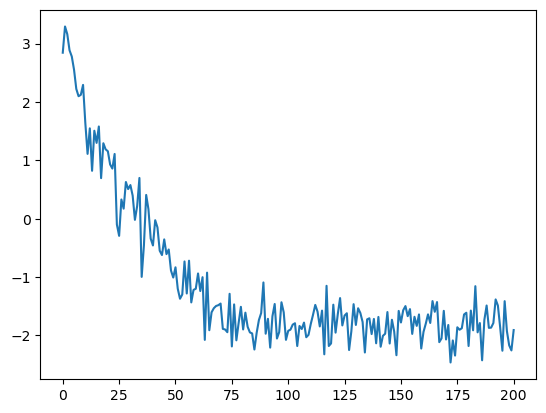

In [3]:
# Clean training
theta_clean_avg = []
loss_clean_avg = []
for trial in range(n_trials_per_delta):
    theta_clean, _, all_losses_clean = RGD(
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    return_losses=True,
                    normalize_grad=normalize_grad
        )

    theta_clean_avg.append(theta_clean)
    loss_clean_avg.append(all_losses_clean[-1])
    
theta_clean = np.mean(theta_clean_avg, axis=0)
loss_clean = np.mean(loss_clean_avg)

plt.plot(all_losses_clean)

### Black Box Attack

In [4]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=black_box_poison_orthogonal,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad,
                return_losses=True,
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-convex/RGD/non-convex_RGD_black_box.pkl', 'wb'))

100%|██████████| 49/49 [01:03<00:00,  1.30s/it]


### White Box Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=white_box_poison_function,
                theta_update_estimator=RGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad,
                return_losses=True,
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-convex/RGD/non-convex_RGD_white_box.pkl', 'wb'))

 47%|████▋     | 23/49 [04:50<09:00, 20.79s/it]

### Oracle Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    poison_function=oracle_poison_function,
                    theta_update_estimator=RGD_update_estimator,
                    sampling_estimator=gaussian_sampling_estimator,
                    sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
                    poison_steps=int(float(delta)//poison_step_size) + 1,
                    poison_step_size=poison_step_size,
                    epsilon=epsilon,
                    delta=delta,
                    return_losses=True,
                    norm=norm,
                    normalize_grad=normalize_grad
        )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-convex/RGD/non-convex_RGD_oracle.pkl', 'wb'))

100%|██████████| 49/49 [17:26<00:00, 21.36s/it]


### Plots

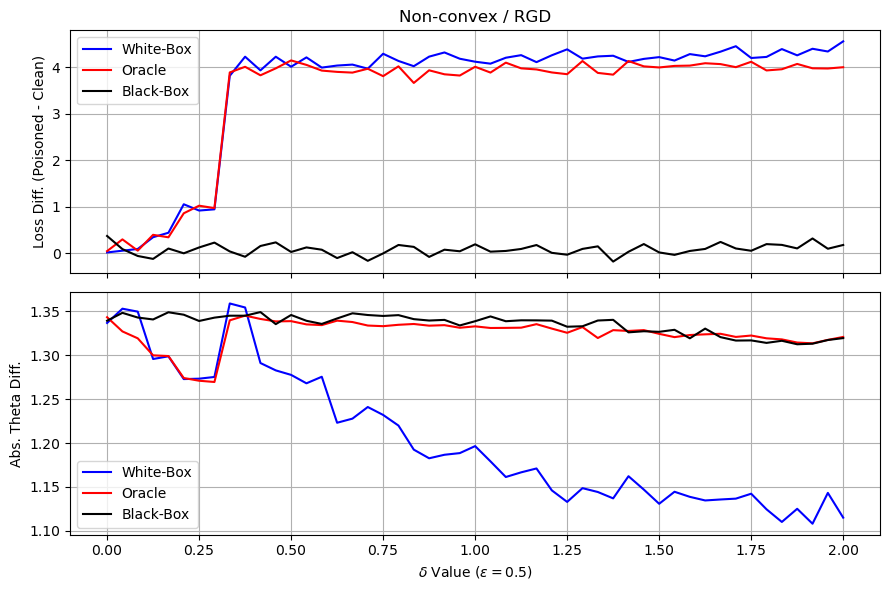

In [ ]:
white_box_data = pickle.load(open('../exports/non-convex/RGD/non-convex_RGD_white_box.pkl', 'rb'))
oracle_data = pickle.load(open('../exports/non-convex/RGD/non-convex_RGD_oracle.pkl', 'rb'))
black_box_data = pickle.load(open('../exports/non-convex/RGD/non-convex_RGD_black_box.pkl', 'rb'))

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Top: loss difference
axes[0].plot(white_box_data["delta_vals"], white_box_data["loss_diff"], label="White-Box", color="blue")
axes[0].plot(oracle_data["delta_vals"], oracle_data["loss_diff"], label="Oracle", color="red")
axes[0].plot(black_box_data["delta_vals"], black_box_data["loss_diff"], label="Black-Box", color="black")
axes[0].set_ylabel("Loss Diff. (Poisoned - Clean)")
axes[0].set_title("Non-convex / RGD")
axes[0].legend()
axes[0].grid(True)

# Bottom: theta difference
axes[1].plot(white_box_data["delta_vals"], np.linalg.norm(white_box_data["theta_diff"], axis=1), label="White-Box", color="blue")
axes[1].plot(oracle_data["delta_vals"], np.linalg.norm(oracle_data["theta_diff"], axis=1), label="Oracle", color="red")
axes[1].plot(black_box_data["delta_vals"], np.linalg.norm(black_box_data["theta_diff"], axis=1), label="Black-Box", color="black")
axes[1].set_ylabel("Theta Diff. Norm")
axes[1].set_xlabel(r"$\delta$ Value ($\epsilon=0.5$)")

axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## PerfGD

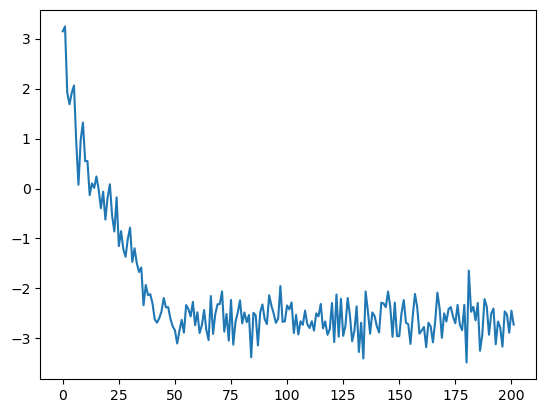

In [ ]:
eta = 0.1 # PerfGD needs higher learning rate 
delta_vals = [0.5, 1.0, 2.0] # Just to speed this up LOL

# Clean training
theta_clean_avg = []
loss_clean_avg = []
for trial in range(n_trials_per_delta):
    theta_clean, all_theta_clean, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                normalize_grad=normalize_grad
    )

    theta_clean_avg.append(theta_clean)
    loss_clean_avg.append(all_losses_clean[-1])
    
theta_clean = np.mean(theta_clean_avg, 0)
loss_clean = np.mean(loss_clean_avg)

plt.plot(all_losses_clean)

### Black Box Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=black_box_poison_orthogonal,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-convex/PerfGD/non-convex_PerfGD_black_box.pkl', 'wb'))

100%|██████████| 3/3 [01:41<00:00, 33.83s/it]


### White Box Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=white_box_poison_function,
                theta_update_estimator=PerfGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-convex/PerfGD/non-convex_PerfGD_white_box.pkl', 'wb'))

  0%|          | 0/3 [03:07<?, ?it/s]


KeyboardInterrupt: 

### Oracle Attack

In [ ]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=oracle_poison_function,
                theta_update_estimator=PerfGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                sampling_estimator=gaussian_sampling_estimator,
                sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
                normalize_grad=normalize_grad
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-convex/PerfGD/non-convex_PerfGD_oracle.pkl', 'wb'))

### Plots

In [ ]:
white_box_data = pickle.load(open('../exports/non-convex/PerfGD/non-convex_PerfGD_white_box.pkl', 'rb'))
oracle_data = pickle.load(open('../exports/non-convex/PerfGD/non-convex_PerfGD_oracle.pkl', 'rb'))
black_box_data = pickle.load(open('../exports/non-convex/PerfGD/non-convex_PerfGD_black_box.pkl', 'rb'))

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Top: loss difference
axes[0].plot(white_box_data["delta_vals"], white_box_data["loss_diff"], label="White-Box", color="blue")
axes[0].plot(oracle_data["delta_vals"], oracle_data["loss_diff"], label="Oracle", color="red")
axes[0].plot(black_box_data["delta_vals"], black_box_data["loss_diff"], label="Black-Box", color="black")
axes[0].set_ylabel("Loss Diff. (Poisoned - Clean)")
axes[0].set_title("Non-convex / PerfGD")
axes[0].legend()
axes[0].grid(True)

# Bottom: theta difference
axes[1].plot(white_box_data["delta_vals"], np.linalg.norm(white_box_data["theta_diff"], axis=1), label="White-Box", color="blue")
axes[1].plot(oracle_data["delta_vals"], np.linalg.norm(oracle_data["theta_diff"], axis=1), label="Oracle", color="red")
axes[1].plot(black_box_data["delta_vals"], np.linalg.norm(black_box_data["theta_diff"], axis=1), label="Black-Box", color="black")
axes[1].set_ylabel("Theta Diff. Norm")
axes[1].set_xlabel(r"$\delta$ Value ($\epsilon=0.5$)")

axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Table

In [ ]:
root = "../exports/"
delta_vals = [0.5, 1.0, 2.0]

for data_model in ["non-linear-means", "classification", "non-convex"]:
    for method in ["RGD", "PerfGD"]:
        for attack in ["white_box", "oracle"]: # ["black_box", "white_box", "oracle"]:
            data = pickle.load(open(f'{root}{data_model}/{method}/{data_model}_{method}_{attack}.pkl', 'rb'))
            for delta in delta_vals:
                idx = np.where(np.isclose(data["delta_vals"], delta))[0][0]
                print(f"{data_model} | {method} | {attack} | delta={delta}: Loss Diff = {data['loss_diff'][idx]:.4f}")